In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# import DataSet
data = pd.read_csv("Social_Network_Ads.csv")

In [12]:
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [13]:
data.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [14]:
# Traintest split
from sklearn.model_selection import train_test_split
X = data[['Age','EstimatedSalary']]
y = data['Purchased']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
# Featrure Scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# model building
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [18]:
### Prediction 
# y_pred = knn.prdict(X_test)

In [19]:
# confusion matrx
# from sklearn

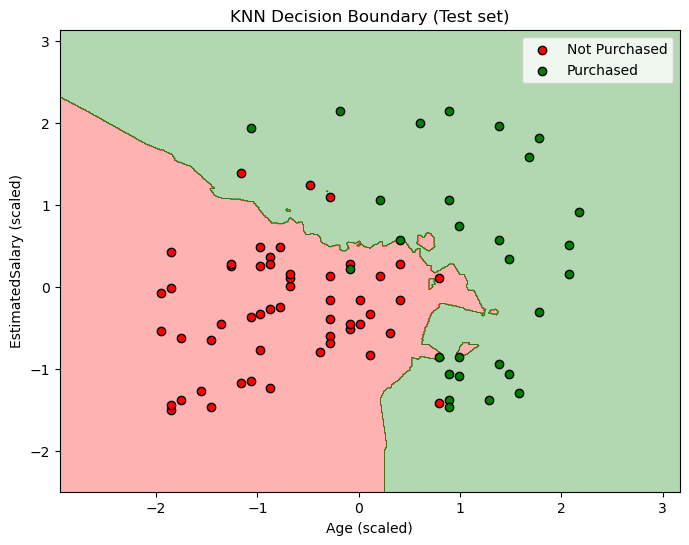

In [20]:
# Plot KNN decision boundary and test points
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Use the test set (X_test is scaled numpy array)
X_set = X_test
y_set = y_test.values if hasattr(y_test, 'values') else y_test

# Create meshgrid over feature space
x1_min, x1_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
x2_min, x2_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.01),
                       np.arange(x2_min, x2_max, 0.01))

# Predict for each point on the grid
grid_points = np.c_[xx1.ravel(), xx2.ravel()]
Z = knn.predict(grid_points)
Z = Z.reshape(xx1.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=ListedColormap(('red', 'green')))

# Scatter test points with true labels
plt.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1], c='red', edgecolor='k', label='Not Purchased')
plt.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1], c='green', edgecolor='k', label='Purchased')

plt.title('KNN Decision Boundary (Test set)')
plt.xlabel('Age (scaled)')
plt.ylabel('EstimatedSalary (scaled)')
plt.legend()
plt.show()
